# Controlling the labjack output power with python 
awojdyla@lbl.gov, andrewlindburg@lbl.gov, Feb 2026

We want to control the output power of a laser using a labjack T8


In [28]:
from labjack import ljm
import time
from pypylon import pylon
import numpy as np
import matplotlib.pyplot as plt

In [29]:
def open_camera(device_index=0, exposure_us=3.5e5):
    """
    Open a Basler camera with 12-bit Mono12p settings.

    Parameters:
        device_index : int
            Index of the camera to open (default: 0).
        exposure_us : float
            Exposure time in microseconds (default: 350000 us = 350 ms).

    Returns:
        camera : pylon.InstantCamera
            Opened and configured camera object.
        converter : pylon.ImageFormatConverter
            Image converter for Mono16 output.
    """

    # Create the transport layer factory
    tl_factory = pylon.TlFactory.GetInstance()

    # Enumerate connected devices
    devices = tl_factory.EnumerateDevices()
    if len(devices) == 0:
        raise RuntimeError("No Basler cameras found!")

    if device_index >= len(devices):
        raise ValueError(f"device_index {device_index} out of range ({len(devices)} devices found)")

    # Create camera
    camera = pylon.InstantCamera(tl_factory.CreateDevice(devices[device_index]))
    camera.Open()
    print("Connected to:", camera.GetDeviceInfo().GetModelName())

    # Configure pixel format and bit depth
    camera.PixelFormat.Value = "Mono12p"  # 12-bit unpacked
    camera.BslSensorBitDepthMode.Value = "Manual"
    camera.BslSensorBitDepth.Value = "Bpp12"
    camera.ExposureTime.Value = exposure_us
    camera.Gain.Value = 5

    # Setup converter to Mono16 (preserves 12-bit values)
    converter = pylon.ImageFormatConverter()
    converter.OutputPixelFormat = pylon.PixelType_Mono16
    converter.OutputBitAlignment = pylon.OutputBitAlignment_MsbAligned

    return camera, converter

def capture_image(camera, converter, extra_margin_ms=500):
    """
    Capture one image with timeout automatically matched to exposure time.
    """

    # Exposure is in microseconds
    exposure_us = camera.ExposureTime.Value
    exposure_ms = exposure_us / 1000.0

    # Timeout = exposure + margin
    timeout_ms = int(exposure_ms * 1.5 + extra_margin_ms)

    if not camera.IsGrabbing():
        camera.StartGrabbing(pylon.GrabStrategy_OneByOne)

    grab = camera.RetrieveResult(timeout_ms, pylon.TimeoutHandling_ThrowException)

    if not grab.GrabSucceeded():
        grab.Release()
        raise RuntimeError("Camera failed to capture image")

    img = converter.Convert(grab).GetArray().astype(np.float32)
    grab.Release()

    # Convert 16-bit container → true 12-bit
    img_12bit = img / 16.0
    return img_12bit

### Take a picture and integrate intensity on camera

In [40]:
# Configure exposure and voltage steps
exposure_time_us = 15.
voltage_step = 0.005
voltages = np.arange(0, 0.5 + voltage_step, voltage_step)

# Saturation value for 12-bit images
sat_val = 4095

# Laser handle
handle = ljm.openS("T8", "ANY", "ANY")

# Open camera and set gain value
camera, converter = open_camera(device_index=1, exposure_us=exposure_time_us)
camera.Gain.Value = 0.0

# Create array to store intensity sums for each voltage
intensity_sums = np.zeros(len(voltages), dtype=np.float32)

try:
    # Ensure laser is off for background capture
    ljm.eWriteName(handle, "DAC1", 0.0)
    time.sleep(0.2)

    # Capture background image and sum for later subtraction
    background_img = capture_image(camera, converter).astype(np.int32)
    background_sum = np.sum(background_img)

    # Create correct number of subplots automatically
    # fig_img, axes = plt.subplots(
    #     1, len(voltages),
    #     figsize=(3 * len(voltages), 3),
    #     constrained_layout=True
    # )

    # Ensure axes is iterable even if only 1 voltage
    # if len(voltages) == 1:
    #     axes = [axes]

    for i, voltage in enumerate(voltages):

        # Set voltage
        ljm.eWriteName(handle, "DAC1", float(voltage))
        time.sleep(0.1)  # allow laser to settle

        # Capture image
        img_12bit = capture_image(camera, converter)

        # Check for saturation
        if np.max(img_12bit) >= sat_val:
            print("Warning: Image is saturated at voltage {:.2f} V".format(voltage))

        # Subtract background and store total intensity
        img_12bit -= background_img

        # Store total intensity
        intensity_sums[i] = np.sum(img_12bit) - background_sum

        # Plot image
    #     ax = axes[i]
    #     im = ax.imshow(img_12bit, cmap='viridis')
    #     ax.set_title(f"{voltage:.2f} V")
    #     ax.axis("off")

    # fig_img.colorbar(im, ax=axes)
    # plt.show()

finally:
    # Always turn laser and camera off before closing
    ljm.eWriteName(handle, "DAC1", 0.0)
    ljm.close(handle)
    camera.Close()

Connected to: dmA4096-9gm


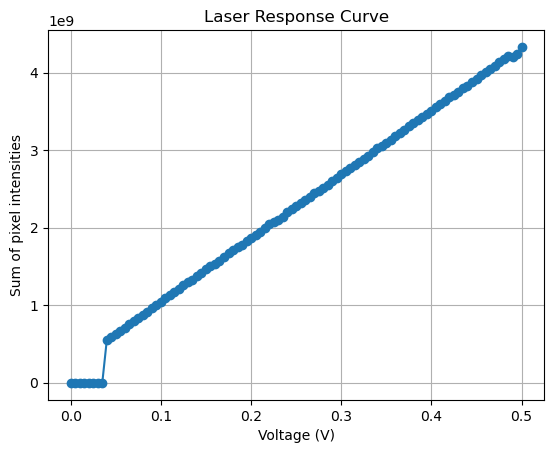

In [41]:
# Plot intensity vs voltage
plt.figure()
plt.plot(voltages, intensity_sums, 'o-')
plt.xlabel("Voltage (V)")
plt.ylabel("Sum of pixel intensities")
plt.title("Laser Response Curve")
plt.grid(True)
plt.show()

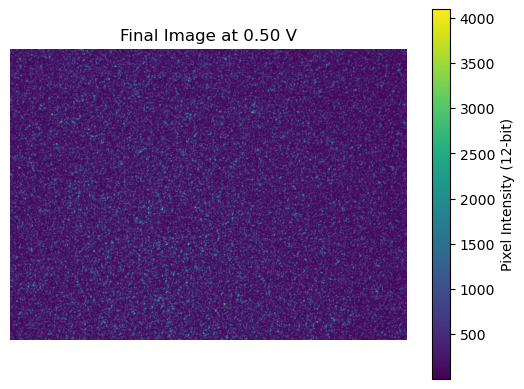

In [39]:
# Plot final image
plt.figure()
plt.imshow(img_12bit, cmap='viridis')
plt.colorbar(label="Pixel Intensity (12-bit)")
plt.title(f"Final Image at {voltage:.2f} V")
plt.axis("off")
plt.show()

In [32]:
camera.Close()